In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from scipy.stats import spearmanr
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from hmmlearn import hmm
import joblib, warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Global knobs ─────────────────────────────────────────────────────────────
DATA_PATH    = '/Users/mikayilmajidov/Projects/Monolith_moextrade/tables/candles.xlsx'
START_DATE   = '2022-01-21'
N_HMM_STATES = 4
RANDOM_SEED  = 42
MAX_RANGE    = 0.03

# Update STATE_TO_REGIME after inspecting emission means in Section 8.3
STATE_TO_REGIME = {0: 'Uptrend', 1: 'Downtrend', 2: 'MeanReversion', 3: 'Undefined'}
REGIME_COLORS   = {'Uptrend': 'green', 'Downtrend': 'red',
                   'MeanReversion': 'royalblue', 'Undefined': 'gray'}
STATE_COLORS    = ['green', 'red', 'royalblue', 'gray', 'orange', 'purple']
print('Libraries loaded')

Libraries loaded


## 1. Data Loading & Cleaning

In [2]:
def load_clean_candles(path, start='2022-01-01'):
    """
    Load 5-min CNYRUB_TOM candles. Derived columns:
      return, log_return, ma_short (5), ma_long (20), ma_bullish.
    Weekends filtered out; sorted ascending by datetime.
    """
    df = pd.read_excel(path, index_col=None)
    df['datetime'] = pd.to_datetime(df['tradedate'].astype(str) + ' ' + df['tradetime'].astype(str))
    df.set_index('datetime', inplace=True)
    df = df[df.index > start]
    df = df[df.index.dayofweek < 5]
    df.sort_index(inplace=True)
    df['return']     = df['pr_close'].pct_change()
    df['log_return'] = np.log(df['pr_close'] / df['pr_close'].shift(1))
    df['ma_short']   = df['pr_close'].rolling(5).mean()
    df['ma_long']    = df['pr_close'].rolling(20).mean()
    df['ma_bullish'] = (df['ma_short'] > df['ma_long']).astype(float)
    return df


candles = load_clean_candles(DATA_PATH, start=START_DATE)
print(f'Rows: {len(candles):,}  |  {candles.index[0].date()} to {candles.index[-1].date()}')
candles[['pr_close','vol_b','vol_s','log_return']].describe().round(6)

,pr_close,vol_b,vol_s,log_return
count,116540.000000,1.165400e+05,1.165400e+05,116539.000000
mean,11.685969,3.733051e+04,3.702355e+04,-0.000000
std,1.768086,1.125388e+05,9.247050e+04,0.001902
min,7.508700,0.000000e+00,0.000000e+00,-0.101785
25%,10.898000,5.487750e+03,4.958000e+03,-0.000350
50%,11.955000,1.895100e+04,2.030400e+04,0.000000
75%,12.738000,4.203525e+04,4.494475e+04,0.000353
max,23.012600,7.886422e+06,6.100973e+06,0.080184


## 2. Daily Feature Engineering

| Feature | Construction | Economic meaning |
|---|---|---|
| `spearman_trend` | Spearman rho(time, close) | Directional persistence |
| `hurst` | Log-variance slope/2 | Long-memory vs. MR |
| `lag1_autocorr` | Pearson lag-1 autocorr | Short-horizon momentum |
| `volatility` | Std of intraday log-returns | Regime intensity |
| `avg_disb` | (vol_b−vol_s)/total | Net directional flow |
| `trade_imb` | (trades_b−trades_s)/total | Trade-count imbalance |
| `vol_concentration` | vol_b/total | Buy-side dominance |
| `norm_range` | (H−L)/Open | Intraday range |
| `ma_diff` | MA(5)−MA(20) | MA momentum |
| `ma_crossover` | Binary: MA(5)>MA(20) | Trend flag |
| `dow_sin/cos` | Circular weekday encoding | Seasonality |
| `intraday_reversal` | first_half_ret × second_half_ret | Reversal pattern |
| `vwap_distance` | (close−VWAP)/VWAP | Close vs. VWAP |
| `tick_intensity` | bars/(bars+1) | Activity proxy |

In [3]:
def compute_hurst(returns, min_lag=5, max_lag=20):
    """
    Hurst exponent via log-variance regression.
    H > 0.5 trending, H < 0.5 mean-reverting, H = 0.5 random walk.
    Clipped to (0.01, 0.99) for numerical stability.
    """
    returns = np.array(returns)
    if len(returns) < max_lag + 1: return np.nan
    lags = range(min_lag, min(max_lag, len(returns)//2))
    if len(lags) < 2: return np.nan
    variances = []
    for lag in lags:
        agg = [np.sum(returns[i:i+lag]) for i in range(0, len(returns)-lag, lag)]
        if len(agg) >= 2: variances.append(np.var(agg, ddof=1))
    if len(variances) < 2: return np.nan
    try:
        slope = np.polyfit(np.log(list(lags)[:len(variances)]), np.log(variances), 1)[0]
        return float(np.clip(slope/2.0, 0.01, 0.99))
    except: return np.nan


def compute_daily_features(df_intraday):
    """
    Aggregate 5-min bars to one row per day. Sessions < 10 bars dropped.
    """
    df_intraday = df_intraday.copy()
    for col in ['vol_b','vol_s','trades_b','trades_s']:
        if col not in df_intraday.columns: df_intraday[col] = 0

    records = []
    for day, g in df_intraday.groupby(df_intraday.index.date):
        if len(g) < 10: continue
        closes   = g['pr_close'].values
        log_rets = g['log_return'].values[1:]
        returns  = g['return'].values[1:]

        rho, _        = spearmanr(np.arange(len(closes)), closes)
        hurst         = compute_hurst(log_rets, 5, 20)
        if np.isnan(hurst): hurst = 0.5
        lag1_autocorr = np.corrcoef(returns[:-1], returns[1:])[0,1] if len(returns)>=3 else 0.0
        volatility    = np.std(log_rets, ddof=1) if len(log_rets)>1 else 0.0

        vol_b = g['vol_b'].sum(); vol_s = g['vol_s'].sum()
        tr_b  = g['trades_b'].sum(); tr_s = g['trades_s'].sum()
        tot_v = vol_b+vol_s+1e-9; tot_t = tr_b+tr_s+1e-9

        day_open   = g['pr_open'].iloc[0]
        norm_range = (g['pr_high'].max()-g['pr_low'].min())/day_open if day_open!=0 else 0.0

        mid      = len(closes)//2
        fh_ret   = (closes[mid]-closes[0])/closes[0] if closes[0]!=0 else 0
        sh_ret   = (closes[-1]-closes[mid])/closes[mid] if closes[mid]!=0 else 0
        reversal = fh_ret*sh_ret

        vwap = (g['pr_close']*(g['vol_b']+g['vol_s'])).sum()/(g['vol_b']+g['vol_s']).sum()
        vwap_dist = (closes[-1]-vwap)/vwap if vwap!=0 else 0

        dow = pd.Timestamp(day).dayofweek
        records.append({
            'date': pd.Timestamp(day),
            'spearman_trend': rho, 'hurst': hurst,
            'lag1_autocorr': lag1_autocorr, 'volatility': volatility,
            'avg_disb': (vol_b-vol_s)/tot_v, 'trade_imb': (tr_b-tr_s)/tot_t,
            'vol_concentration': vol_b/tot_v, 'norm_range': norm_range,
            'ma_diff': g['ma_short'].iloc[-1]-g['ma_long'].iloc[-1],
            'ma_crossover': 1.0 if g['ma_short'].iloc[-1]>g['ma_long'].iloc[-1] else 0.0,
            'dow_sin': np.sin(2*np.pi*dow/5.0), 'dow_cos': np.cos(2*np.pi*dow/5.0),
            'intraday_reversal': reversal, 'vwap_distance': vwap_dist,
            'tick_intensity': len(g)/(len(g)+1),
        })
    return pd.DataFrame(records).set_index('date').sort_index()


df_daily = compute_daily_features(candles)
print(f'Daily feature table: {df_daily.shape}')
df_daily.describe().round(4)

,spearman_trend,hurst,lag1_autocorr,volatility,avg_disb,trade_imb,vol_concentration,norm_range,ma_diff,ma_crossover,dow_sin,dow_cos,intraday_reversal,vwap_distance,tick_intensity
count,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000,920.0000
mean,-0.0534,0.4268,-0.0671,0.0011,0.0034,-0.0250,0.5017,0.0194,0.0004,0.5283,-0.0018,-0.0047,0.0000,0.0008,0.9920
std,0.6283,0.1980,0.1442,0.0014,0.1593,0.1851,0.0796,0.0228,0.0244,0.4995,0.7087,0.7062,0.0003,0.0091,0.0012
min,-0.9775,0.0100,-0.6466,0.0002,-0.5476,-0.6651,0.2262,0.0027,-0.2008,0.0000,-0.9511,-0.8090,-0.0017,-0.0397,0.9891
25%,-0.6500,0.2961,-0.1432,0.0005,-0.1013,-0.1355,0.4494,0.0082,-0.0063,0.0000,-0.5878,-0.8090,-0.0000,-0.0022,0.9908
50%,-0.1625,0.4488,-0.0563,0.0007,-0.0065,-0.0210,0.4968,0.0131,0.0006,1.0000,0.0000,0.3090,-0.0000,0.0002,0.9930
75%,0.5612,0.5716,0.0257,0.0011,0.1013,0.0845,0.5507,0.0208,0.0077,1.0000,0.5878,0.3090,0.0000,0.0029,0.9931
max,0.9832,0.9467,0.3119,0.0216,0.6129,0.7614,0.8065,0.2691,0.2922,1.0000,0.9511,1.0000,0.0078,0.0869,0.9950


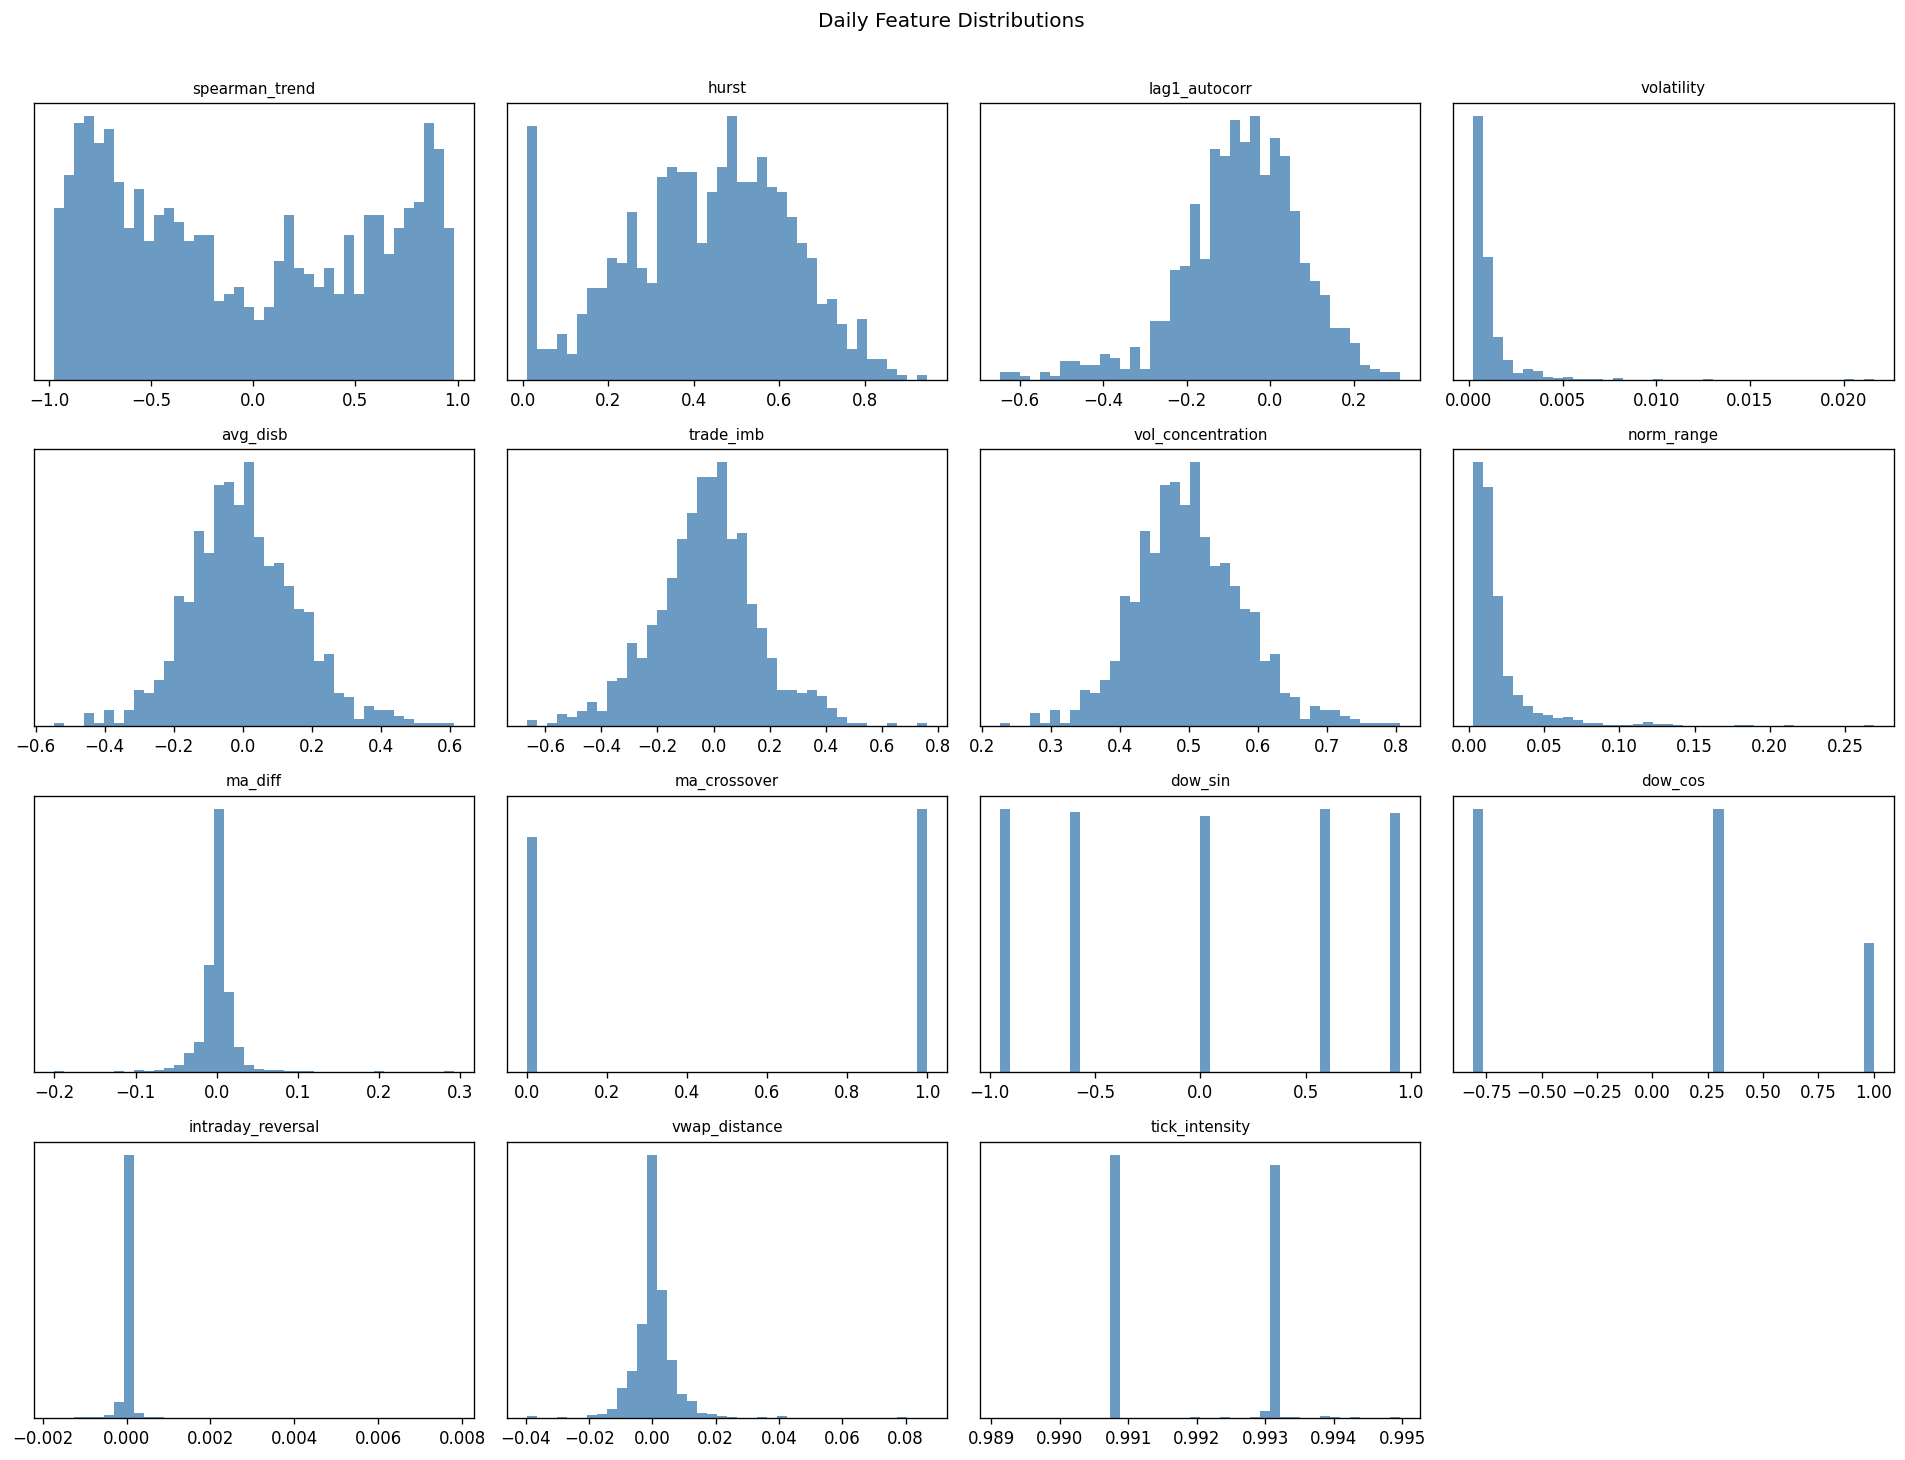

In [4]:
# Feature distribution overview
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()
for i, col in enumerate(df_daily.columns):
    axes[i].hist(df_daily[col].dropna(), bins=40, edgecolor='none', color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=9); axes[i].set_yticks([])
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Daily Feature Distributions', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

## 3. Alpha Features

In [5]:
def add_alpha_features(df):
    """
    Second-order features:
      vol_percentile      : expanding-window rank of volatility (0-1, no look-ahead)
      order_flow_ma3      : 3-day MA of avg_disb
      order_flow_momentum : avg_disb minus its 3-day MA
      hurst_change        : day-on-day Hurst delta
      autocorr_ma5        : 5-day MA of lag1_autocorr
      momentum_score      : rolling(3) spearman * hurst * (1 + flow_mom)
    """
    df = df.copy()
    df['vol_percentile']      = df['volatility'].expanding(min_periods=30).apply(
        lambda x: (x.iloc[-1]-x.min())/(x.max()-x.min()+1e-12))
    df['order_flow_ma3']      = df['avg_disb'].rolling(3).mean()
    df['order_flow_momentum'] = df['avg_disb'] - df['order_flow_ma3']
    df['hurst_change']        = df['hurst'].diff(1)
    df['autocorr_ma5']        = df['lag1_autocorr'].rolling(5).mean()
    df['momentum_score']      = (
        df['spearman_trend'].rolling(3).mean() * df['hurst']
        * (1 + df['order_flow_momentum'].fillna(0)))
    return df


df_daily = add_alpha_features(df_daily)
print('Alpha features added')

Alpha features added


## 4. Rule-Based Regime Labels (Expanding Window)

Used as an interpretability benchmark — not as a training signal.

| Regime | Spearman | Hurst | Norm Range |
|---|---|---|---|
| Uptrend | > +0.75 | > 0.50 | > p30 of history |
| Downtrend | < -0.75 | > 0.50 | > p30 of history |
| MeanReversion | |rho| < 0.25 | < 0.40 | < p60 of history |

Quantile thresholds are recalculated each day using only past data — no look-ahead bias.

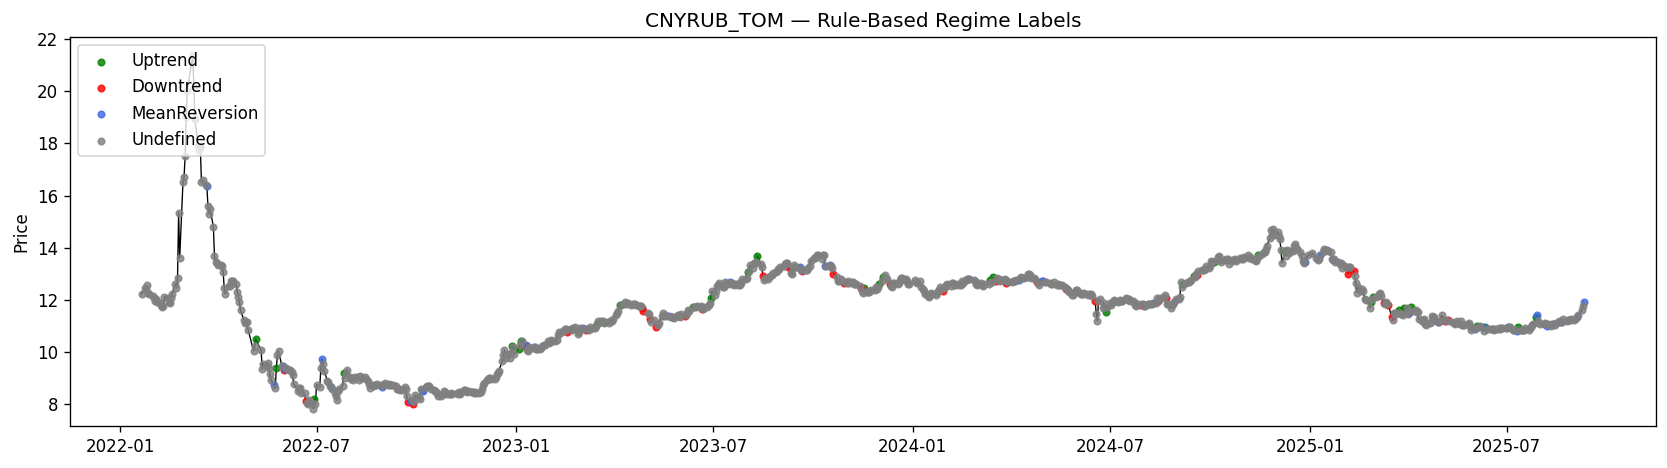

In [6]:
def assign_regimes_expanding(df, min_history=30):
    """
    Assign rule-based regimes using only backward-looking quantiles.
    No day receives a label until min_history prior days exist.
    """
    df = df.copy()
    df['regime'] = 'Undefined'
    for i in range(min_history, len(df)):
        hist = df.iloc[:i+1]
        row  = df.iloc[i]
        p30  = hist['norm_range'].quantile(0.30)
        p60  = hist['norm_range'].quantile(0.60)
        if   row['spearman_trend']>0.75  and row['hurst']>0.50 and row['norm_range']>p30: lbl='Uptrend'
        elif row['spearman_trend']<-0.75 and row['hurst']>0.50 and row['norm_range']>p30: lbl='Downtrend'
        elif abs(row['spearman_trend'])<0.25 and row['hurst']<0.40 and row['norm_range']<p60: lbl='MeanReversion'
        else: lbl='Undefined'
        df.iloc[i, df.columns.get_loc('regime')] = lbl
    return df


df_daily = assign_regimes_expanding(df_daily)
print('Regime counts (rule-based):')
print(df_daily['regime'].value_counts())

fig, ax = plt.subplots(figsize=(14,4))
daily_close = candles['pr_close'].resample('D').last().reindex(df_daily.index)
ax.plot(daily_close.index, daily_close.values, color='black', lw=0.8)
for regime, color in REGIME_COLORS.items():
    mask = df_daily['regime']==regime
    ax.scatter(df_daily.index[mask], daily_close[mask], c=color, s=15, zorder=3, label=regime, alpha=0.8)
ax.set_title('CNYRUB_TOM — Rule-Based Regime Labels'); ax.legend(loc='upper left'); ax.set_ylabel('Price')
plt.tight_layout(); plt.show()

## 5. 3D Regime Visualisation

In [7]:
def plot_regime_space(df, candles, max_range=0.03):
    """Six-panel figure: regime scatter, forward-return coloring, interpolated surface,
    contour heatmap, hexbin avg return, return distribution per regime."""
    daily_close   = candles['pr_close'].resample('D').last()
    daily_returns = daily_close.pct_change().shift(-1)
    df = df.copy()
    df['forward_return'] = df.index.map(daily_returns.to_dict())
    d  = df[df['norm_range']<max_range].dropna(subset=['forward_return']).copy()
    d['color'] = d['regime'].map(REGIME_COLORS).fillna('gray')

    fig = plt.figure(figsize=(20,12))
    gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.4,wspace=0.3)

    ax1 = fig.add_subplot(gs[0,0],projection='3d')
    ax1.scatter(d['spearman_trend'],d['hurst'],d['norm_range'],c=d['color'],alpha=0.6,s=25)
    ax1.set(xlabel='Spearman',ylabel='Hurst',zlabel='Norm Range',title='Rule-Based Regimes')

    ax2 = fig.add_subplot(gs[0,1],projection='3d')
    sc = ax2.scatter(d['spearman_trend'],d['hurst'],d['norm_range'],
                     c=d['forward_return'],cmap='RdYlGn',alpha=0.7,s=25)
    ax2.set(xlabel='Spearman',ylabel='Hurst',zlabel='Norm Range',title='Next-Day Return (Alpha View)')
    fig.colorbar(sc,ax=ax2,label='Fwd Return',shrink=0.6)

    ax3 = fig.add_subplot(gs[0,2],projection='3d')
    x,y,z = d['spearman_trend'].values,d['hurst'].values,d['forward_return'].values
    xi=np.linspace(x.min(),x.max(),50); yi=np.linspace(y.min(),y.max(),50)
    ZI=griddata((x,y),z,np.meshgrid(xi,yi),method='linear')
    surf=ax3.plot_surface(*np.meshgrid(xi,yi),ZI,cmap='RdYlGn',alpha=0.6,edgecolor='none')
    ax3.set(xlabel='Spearman',ylabel='Hurst',zlabel='Exp Return',title='Expected Return Surface')
    fig.colorbar(surf,ax=ax3,shrink=0.6)

    ax4=fig.add_subplot(gs[1,0])
    cf=ax4.tricontourf(d['spearman_trend'],d['hurst'],d['forward_return'],levels=20,cmap='RdYlGn')
    ax4.scatter(d['spearman_trend'],d['hurst'],c='k',s=4,alpha=0.25)
    ax4.set(xlabel='Spearman',ylabel='Hurst',title='Return Heatmap (Top View)')
    fig.colorbar(cf,ax=ax4)

    ax5=fig.add_subplot(gs[1,1])
    hb=ax5.hexbin(d['spearman_trend'],d['hurst'],C=d['forward_return'],
                  gridsize=20,cmap='RdYlGn',reduce_C_function=np.mean)
    ax5.set(xlabel='Spearman',ylabel='Hurst',title='Hexbin Avg Return')
    fig.colorbar(hb,ax=ax5)

    ax6=fig.add_subplot(gs[1,2])
    for regime,color in REGIME_COLORS.items():
        rd=d[d['regime']==regime]['forward_return'].dropna()
        if len(rd)>0: ax6.hist(rd,bins=30,alpha=0.5,color=color,label=f'{regime} mu={rd.mean():.4f}')
    ax6.axvline(0,color='k',ls='--',lw=0.8)
    ax6.set(xlabel='Forward Return',ylabel='Count',title='Return Distribution by Regime')
    ax6.legend(fontsize=8)
    plt.suptitle('Feature-Space Regime Analysis',fontsize=13); plt.show()

    print('\nRegime Forward-Return Statistics:')
    print(f'{"Regime":<17}{"Mean":>8}{"Std":>8}{"Sharpe":>8}{"Win%":>7}{"N":>5}')
    print('-'*55)
    for regime in REGIME_COLORS:
        rd=d[d['regime']==regime]['forward_return'].dropna()
        if len(rd)==0: continue
        mean,std=rd.mean(),rd.std(); sharpe=mean/std if std>0 else 0
        print(f'{regime:<17}{mean:>8.4f}{std:>8.4f}{sharpe:>8.3f}{(rd>0).mean():>7.1%}{len(rd):>5}')


plot_regime_space(df_daily, candles, MAX_RANGE)


Regime Forward-Return Statistics:
Regime               Mean     Std  Sharpe   Win%    N
-------------------------------------------------------
Uptrend            0.0011  0.0067   0.163  33.3%   27
Downtrend         -0.0013  0.0103  -0.129  53.1%   32
MeanReversion     -0.0011  0.0091  -0.126  42.0%   50
Undefined          0.0006  0.0086   0.075  42.6%  676


## 6. HMM Model Specification

### Observation model
Each hidden state $s_t \in \{0,\ldots,K-1\}$ emits a multivariate Gaussian:
$$\mathbf{x}_t \mid s_t=k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

### Transition dynamics
$$P(s_t=j \mid s_{t-1}=i) = A_{ij}, \quad \sum_j A_{ij}=1$$

### Learnable parameters
| Symbol | Dim | Description |
|---|---|---|
| $\boldsymbol{\pi}$ | $K$ | Initial distribution |
| $\mathbf{A}$ | $K{\times}K$ | Transition matrix |
| $\{\boldsymbol{\mu}_k\}$ | $K{\times}D$ | Emission means |
| $\{\boldsymbol{\Sigma}_k\}$ | $K{\times}D{\times}D$ | Emission covariances |

**Estimation:** Baum-Welch (EM). **Decoding:** Viterbi.

**Choices:** `n_components=4`, `covariance_type='full'`, `n_iter=1000`. All features standardised.

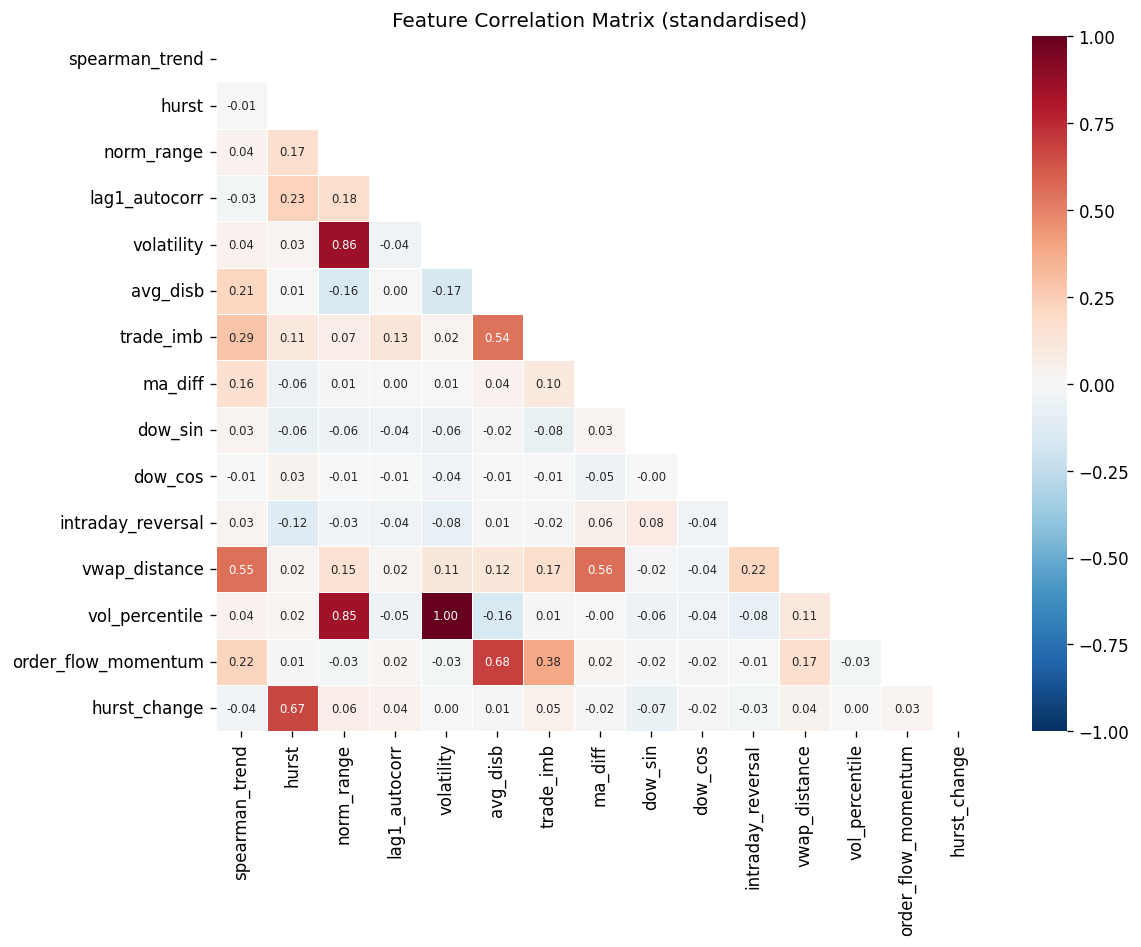

In [8]:
FEATURE_COLS = [
    'spearman_trend','hurst','norm_range','lag1_autocorr','volatility','avg_disb',
    'trade_imb','ma_diff','dow_sin','dow_cos',
    'intraday_reversal','vwap_distance','vol_percentile','order_flow_momentum','hurst_change',
]

df_ml    = df_daily.dropna(subset=FEATURE_COLS).copy()
X        = df_ml[FEATURE_COLS].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Training set : {X_scaled.shape[0]} days x {X_scaled.shape[1]} features')
print(f'Dropped (NaN): {len(df_daily)-len(df_ml)} days')

fig, ax = plt.subplots(figsize=(10,8))
corr = pd.DataFrame(X_scaled, columns=FEATURE_COLS).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7}, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix (standardised)')
plt.tight_layout(); plt.show()

### 6.1 Model Selection — AIC / BIC vs. Number of States

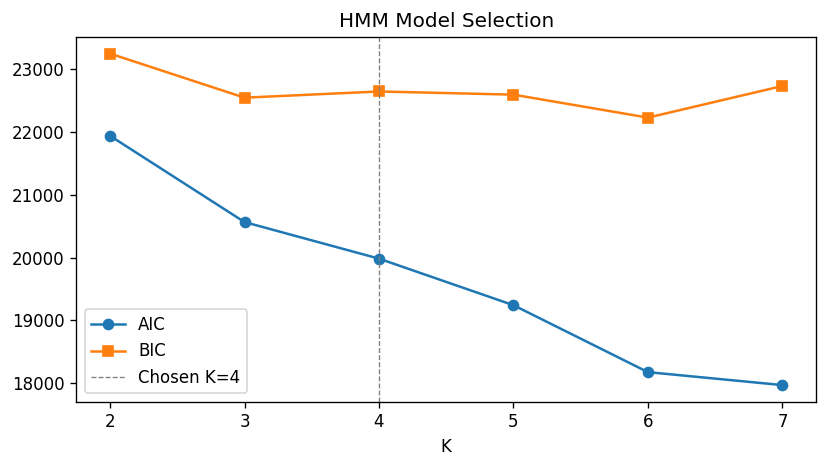

In [9]:
def hmm_information_criteria(X, state_range=range(2,8)):
    """
    Fit GaussianHMM for each K. Free parameters:
      (K-1) + K*(K-1) + K*D + K*D*(D+1)//2
    Returns DataFrame with K, log_likelihood, AIC, BIC, n_params.
    """
    n, D = X.shape; results = []
    for K in state_range:
        try:
            m = hmm.GaussianHMM(n_components=K,covariance_type='full',n_iter=500,random_state=RANDOM_SEED)
            m.fit(X); ll = m.score(X)
            k_par = (K-1)+K*(K-1)+K*D+K*D*(D+1)//2
            results.append({'K':K,'log_likelihood':ll,
                             'AIC':-2*ll+2*k_par,'BIC':-2*ll+k_par*np.log(n),'n_params':k_par})
        except Exception as e: print(f'  K={K} failed: {e}')
    return pd.DataFrame(results)


ic_df = hmm_information_criteria(X_scaled, state_range=range(2,8))
print(ic_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ic_df['K'],ic_df['AIC'],marker='o',label='AIC')
ax.plot(ic_df['K'],ic_df['BIC'],marker='s',label='BIC')
ax.axvline(N_HMM_STATES,color='gray',ls='--',lw=0.8,label=f'Chosen K={N_HMM_STATES}')
ax.set(xlabel='K',title='HMM Model Selection'); ax.legend()
plt.tight_layout(); plt.show()

## 7. HMM Training

In [10]:
model = hmm.GaussianHMM(
    n_components=N_HMM_STATES, covariance_type='full',
    n_iter=1000, random_state=RANDOM_SEED, verbose=False)
model.fit(X_scaled)

hidden_states       = model.predict(X_scaled)
df_ml['hmm_state']  = hidden_states
log_likelihood      = model.score(X_scaled)

print(f'Converged       : {model.monitor_.converged}')
print(f'Log-likelihood  : {log_likelihood:.2f}')
print(f'Iterations used : {len(model.monitor_.history)}')

Converged       : True
Log-likelihood  : -9436.80
Iterations used : 46


## 8. Model Diagnostics

### 8.1 Convergence

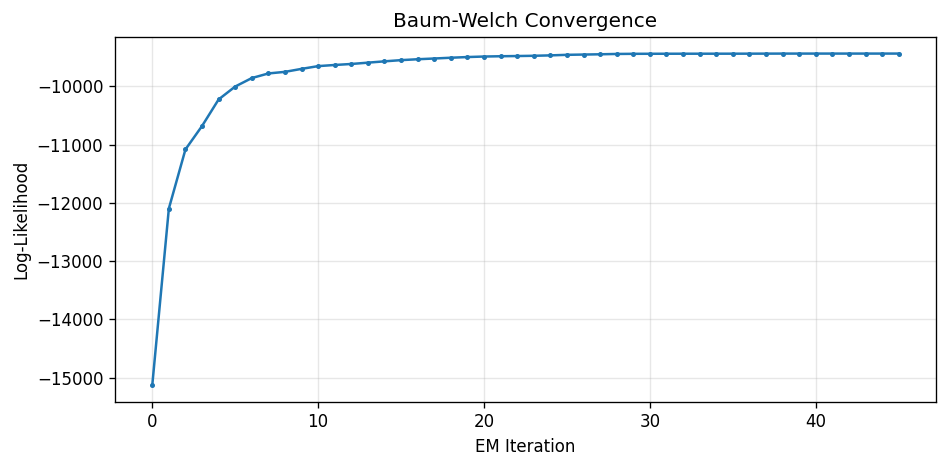

In [11]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(model.monitor_.history, marker='.', markersize=4)
ax.set(xlabel='EM Iteration', ylabel='Log-Likelihood', title='Baum-Welch Convergence')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### 8.2 Transition Matrix

In [12]:
A_df = pd.DataFrame(model.transmat_,
    index=[f'From S{i}' for i in range(N_HMM_STATES)],
    columns=[f'To S{j}' for j in range(N_HMM_STATES)]).round(4)
print('Transition Matrix:'); print(A_df.to_string())

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(model.transmat_,annot=True,fmt='.3f',cmap='Blues',
            xticklabels=[f'S{j}' for j in range(N_HMM_STATES)],
            yticklabels=[f'S{i}' for i in range(N_HMM_STATES)],ax=ax,vmin=0,vmax=1)
ax.set(title='Transition Matrix',xlabel='To',ylabel='From')
plt.tight_layout(); plt.show()

# Expected state duration: E[T|k] = 1/(1 - A_kk)
print('\nExpected durations (days):')
for k in range(N_HMM_STATES):
    s = model.transmat_[k,k]
    dur = 1.0/(1.0-s) if s<1.0 else np.inf
    print(f'  State {k}: self-prob={s:.3f}  duration={dur:.1f} days')


Expected durations (days):
  State 0: self-prob=0.835  duration=6.1 days
  State 1: self-prob=0.628  duration=2.7 days
  State 2: self-prob=0.717  duration=3.5 days
  State 3: self-prob=0.000  duration=1.0 days


### 8.3 Emission Means & Covariance Diagnostics

In [13]:
# Means in original scale
means_orig = scaler.inverse_transform(model.means_)
means_df   = pd.DataFrame(means_orig, columns=FEATURE_COLS,
                           index=[f'State {k}' for k in range(N_HMM_STATES)])

print('State Emission Means (key features, original scale):')
print(means_df[['spearman_trend','hurst','volatility','avg_disb','norm_range','lag1_autocorr']].round(4).to_string())

fig, ax = plt.subplots(figsize=(14,4))
sns.heatmap(means_df.T,annot=True,fmt='.3f',cmap='RdBu_r',center=0,linewidths=0.4,ax=ax)
ax.set_title('Emission Means — update STATE_TO_REGIME based on this')
plt.tight_layout(); plt.show()

# Emission stds + conditioning
print('\nEmission Std Deviations (standardised space):')
stds_df = pd.DataFrame({f'S{k}':np.sqrt(np.diag(model.covars_[k])) for k in range(N_HMM_STATES)},index=FEATURE_COLS)
print(stds_df.round(3).to_string())
print('\nCovariance condition numbers:')
for k in range(N_HMM_STATES):
    print(f'  State {k}: {np.linalg.cond(model.covars_[k]):.1f}')


Emission Std Deviations (standardised space):
                        S0     S1     S2     S3
spearman_trend       0.922  1.097  0.955  0.947
hurst                1.060  0.908  0.962  0.665
norm_range           1.515  0.304  0.159  0.571
lag1_autocorr        1.108  0.775  1.034  0.961
volatility           1.445  0.283  0.245  0.515
avg_disb             1.116  0.878  0.984  1.505
trade_imb            0.685  0.942  1.145  1.238
ma_diff              1.775  0.845  0.308  0.628
dow_sin              0.991  0.987  1.012  0.869
dow_cos              1.008  1.008  0.984  1.057
intraday_reversal    2.083  0.211  0.031  0.413
vwap_distance        1.833  0.754  0.248  1.708
vol_percentile       1.519  0.296  0.261  0.478
order_flow_momentum  1.107  0.926  1.001  0.719
hurst_change         1.056  0.995  0.970  0.652

Covariance condition numbers:
  State 0: 1719.8
  State 1: 27945.2
  State 2: 3482.5
  State 3: 169802578745517248.0


### 8.4 Stationary Distribution

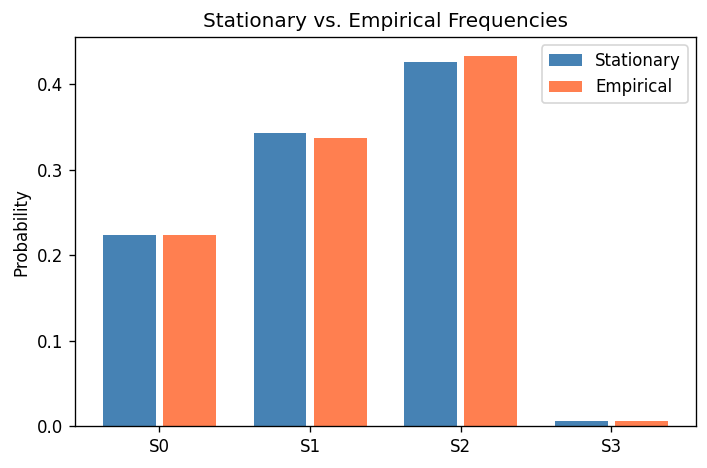

In [14]:
def stationary_distribution(A):
    """
    Solve pi @ A = pi, sum(pi) = 1 via left eigenvector of A.T
    corresponding to eigenvalue 1.
    """
    eigenvalues, eigenvectors = np.linalg.eig(A.T)
    idx = np.argmin(np.abs(eigenvalues-1.0))
    pi  = np.real(eigenvectors[:,idx])
    return pi/pi.sum()


pi       = stationary_distribution(model.transmat_)
emp_freq = np.bincount(hidden_states)/len(hidden_states)
print(f'{"State":<10}{"Stationary":>12}{"Empirical":>12}')
for k in range(N_HMM_STATES): print(f'  {k:<8}{pi[k]:>12.4f}{emp_freq[k]:>12.4f}')

fig, ax = plt.subplots(figsize=(6,4))
x_pos = np.arange(N_HMM_STATES)
ax.bar(x_pos-0.2,pi,      width=0.35,label='Stationary',color='steelblue')
ax.bar(x_pos+0.2,emp_freq,width=0.35,label='Empirical', color='coral')
ax.set(xticks=x_pos,xticklabels=[f'S{k}' for k in range(N_HMM_STATES)],
       ylabel='Probability',title='Stationary vs. Empirical Frequencies')
ax.legend(); plt.tight_layout(); plt.show()

### 8.5 Posterior State Probabilities Over Time

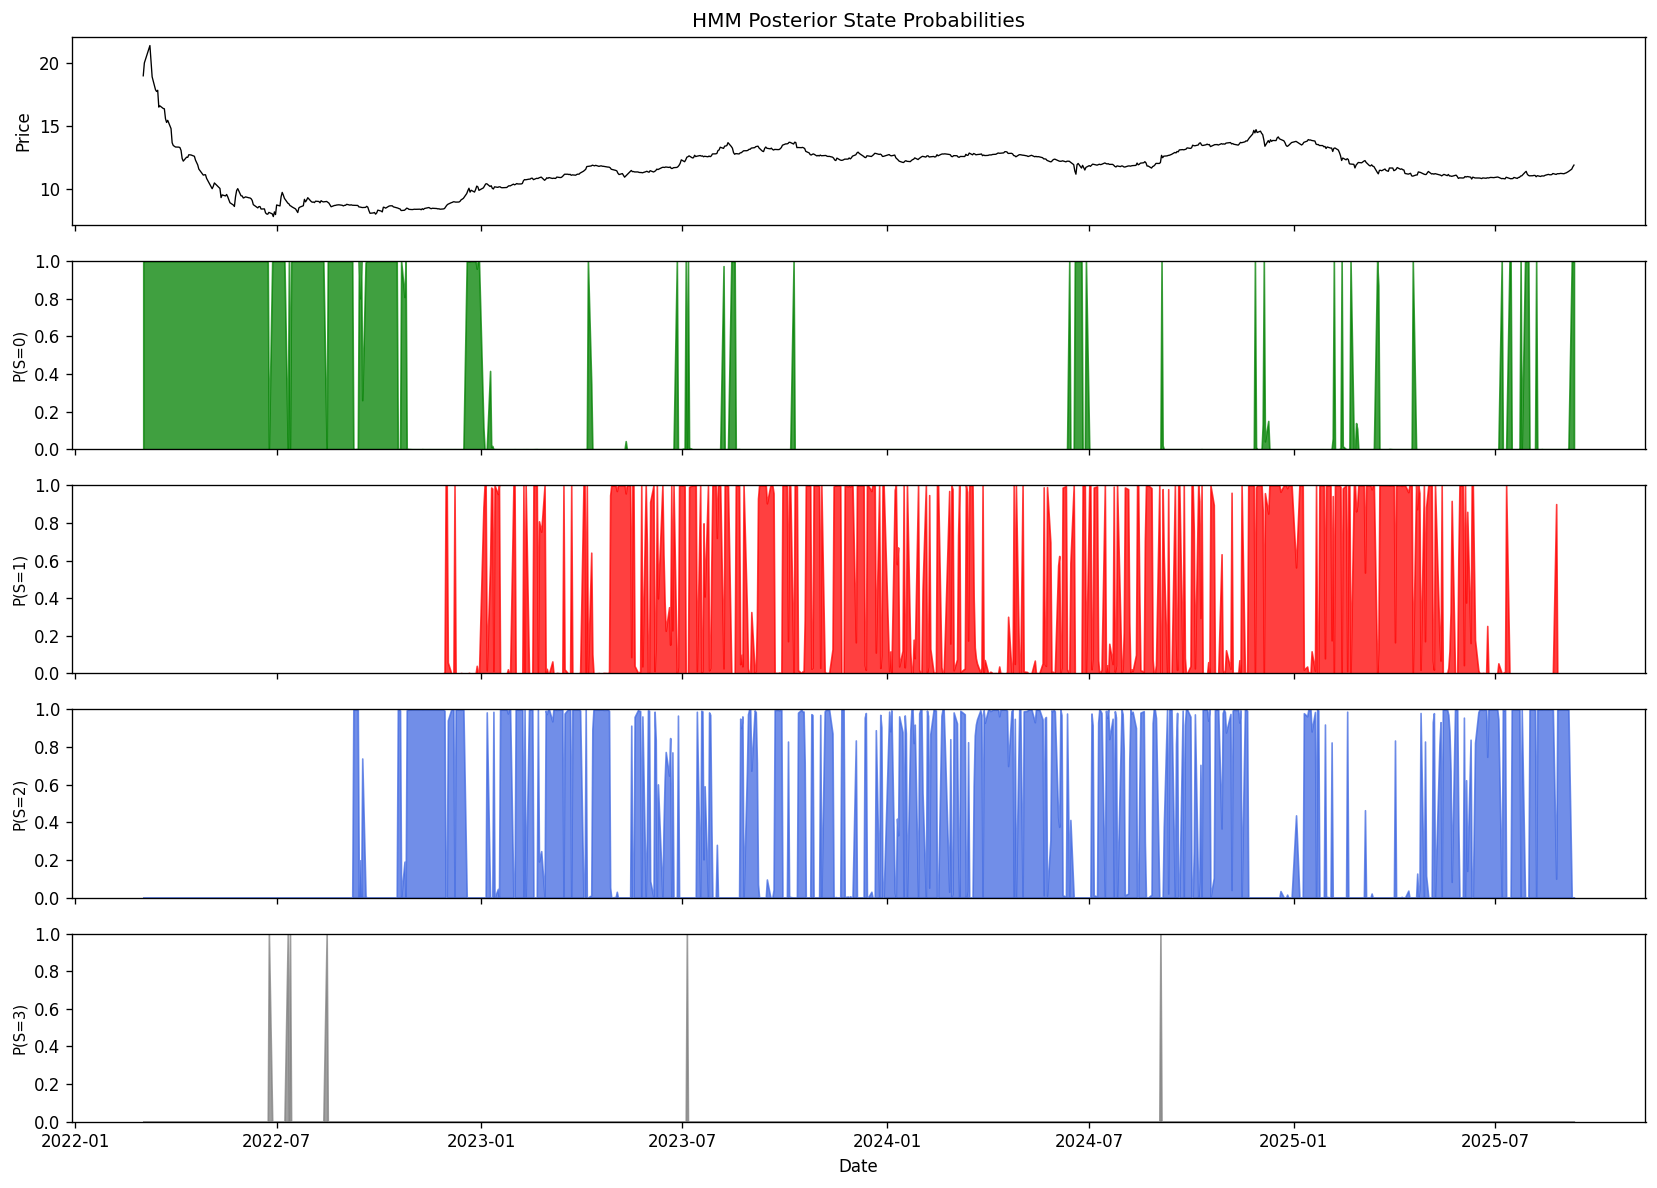

In [15]:
posteriors = model.predict_proba(X_scaled)
fig, axes  = plt.subplots(N_HMM_STATES+1,1,figsize=(14,10),sharex=True)
daily_close_ml = candles['pr_close'].resample('D').last().reindex(df_ml.index)
axes[0].plot(df_ml.index,daily_close_ml.values,lw=0.8,color='black')
axes[0].set_ylabel('Price'); axes[0].set_title('HMM Posterior State Probabilities')
for k in range(N_HMM_STATES):
    axes[k+1].fill_between(df_ml.index,posteriors[:,k],alpha=0.75,color=STATE_COLORS[k])
    axes[k+1].set_ylabel(f'P(S={k})',fontsize=9); axes[k+1].set_ylim(0,1)
axes[-1].set_xlabel('Date'); plt.tight_layout(); plt.show()

### 8.6 HMM States vs. Rule-Based Regimes

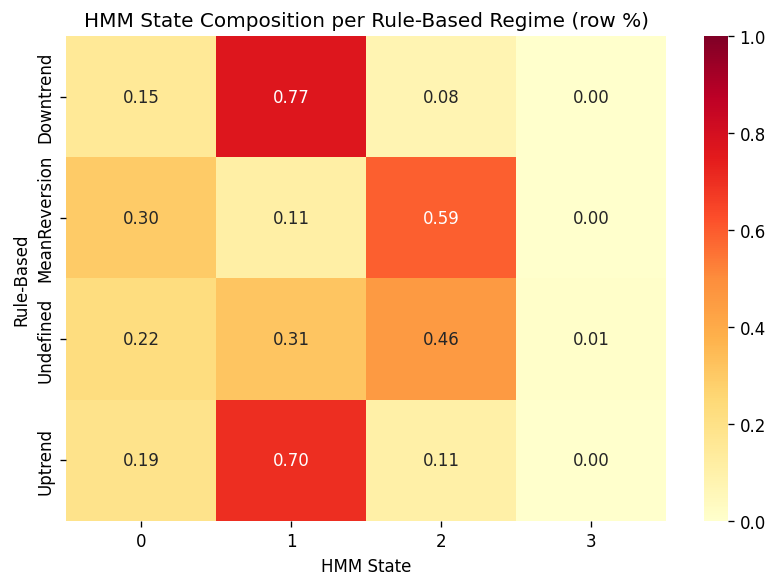

In [16]:
cross      = pd.crosstab(df_ml['regime'],df_ml['hmm_state'],rownames=['Rule-Based'],colnames=['HMM State'])
cross_norm = cross.div(cross.sum(axis=1),axis=0)
print('Cross-tabulation:'); print(cross.to_string())
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(cross_norm,annot=True,fmt='.2f',cmap='YlOrRd',ax=ax,vmin=0,vmax=1)
ax.set_title('HMM State Composition per Rule-Based Regime (row %)')
plt.tight_layout(); plt.show()

### 8.7 Feature Importance — State Separation

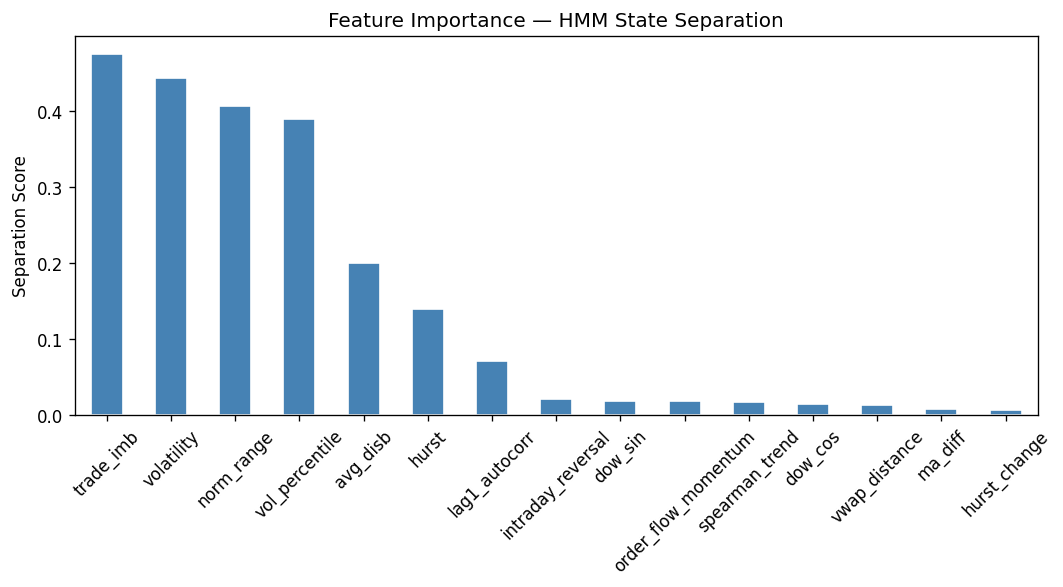

In [17]:
# Inter-state variance / total variance in standardised space
grand_mean = model.means_.mean(axis=0)
inter_var  = np.sum((model.means_-grand_mean)**2,axis=0)/N_HMM_STATES
sep = pd.Series(inter_var/(X_scaled.var(axis=0)+1e-12),index=FEATURE_COLS).sort_values(ascending=False)
print('Feature separation scores:'); print(sep.round(4).to_string())

fig,ax=plt.subplots(figsize=(9,5))
sep.plot(kind='bar',ax=ax,color='steelblue',edgecolor='white')
ax.set(ylabel='Separation Score',title='Feature Importance — HMM State Separation',xlabel='')
ax.tick_params(axis='x',rotation=45); plt.tight_layout(); plt.show()

## 9. One-Step-Ahead Prediction

For each day $t$, decode Viterbi on $\mathbf{x}_{0:t-1}$ to obtain $\hat{s}_{t-1}$, then:
$$\hat{s}_t = \arg\max_j\; A_{\hat{s}_{t-1},j}$$

Strictly causal — no information from day $t$ is used.

In [18]:
def one_step_ahead_predictions(X, model):
    """
    Causal one-step-ahead prediction via sequential Viterbi decode.
    Complexity O(T^2) — replace with online forward filter for large T.
    Returns y_pred (T-1,) and pred_probs (T-1, K).
    """
    T,K = len(X),model.n_components
    y_pred     = np.zeros(T-1,dtype=int)
    pred_probs = np.zeros((T-1,K))
    for t in range(1,T):
        _,states = model.decode(X[:t],algorithm='viterbi')
        row = model.transmat_[states[-1]]
        y_pred[t-1]=np.argmax(row); pred_probs[t-1]=row
    return y_pred, pred_probs


print('Computing predictions (may take a minute)...')
y_pred, pred_probs = one_step_ahead_predictions(X_scaled, model)
y_true = hidden_states[1:]

print(f'\nAccuracy vs. full-sample Viterbi: {accuracy_score(y_true,y_pred):.2%}')
print()
print(classification_report(y_true,y_pred,target_names=[f'State {k}' for k in range(N_HMM_STATES)]))


Accuracy vs. full-sample Viterbi: 69.89%

              precision    recall  f1-score   support

     State 0       0.83      0.86      0.85       198
     State 1       0.60      0.60      0.60       300
     State 2       0.70      0.71      0.71       386
     State 3       0.00      0.00      0.00         6

    accuracy                           0.70       890
   macro avg       0.53      0.54      0.54       890
weighted avg       0.69      0.70      0.70       890



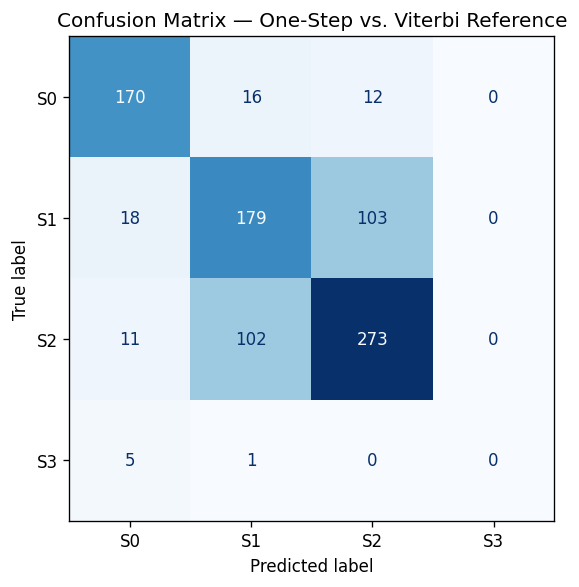

In [19]:
fig,ax=plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_true,y_pred,display_labels=[f'S{k}' for k in range(N_HMM_STATES)],
    ax=ax,colorbar=False,cmap='Blues')
ax.set_title('Confusion Matrix — One-Step vs. Viterbi Reference')
plt.tight_layout(); plt.show()

# Build results DataFrame
dates_pred = df_ml.index[1:]
df_result  = pd.DataFrame(index=dates_pred)
df_result['true_state']=y_true; df_result['pred_state']=y_pred
for k in range(N_HMM_STATES): df_result[f'prob_state_{k}']=pred_probs[:,k]
df_result['pred_regime']=df_result['pred_state'].map(STATE_TO_REGIME)
df_result['true_regime']=df_result['true_state'].map(STATE_TO_REGIME)

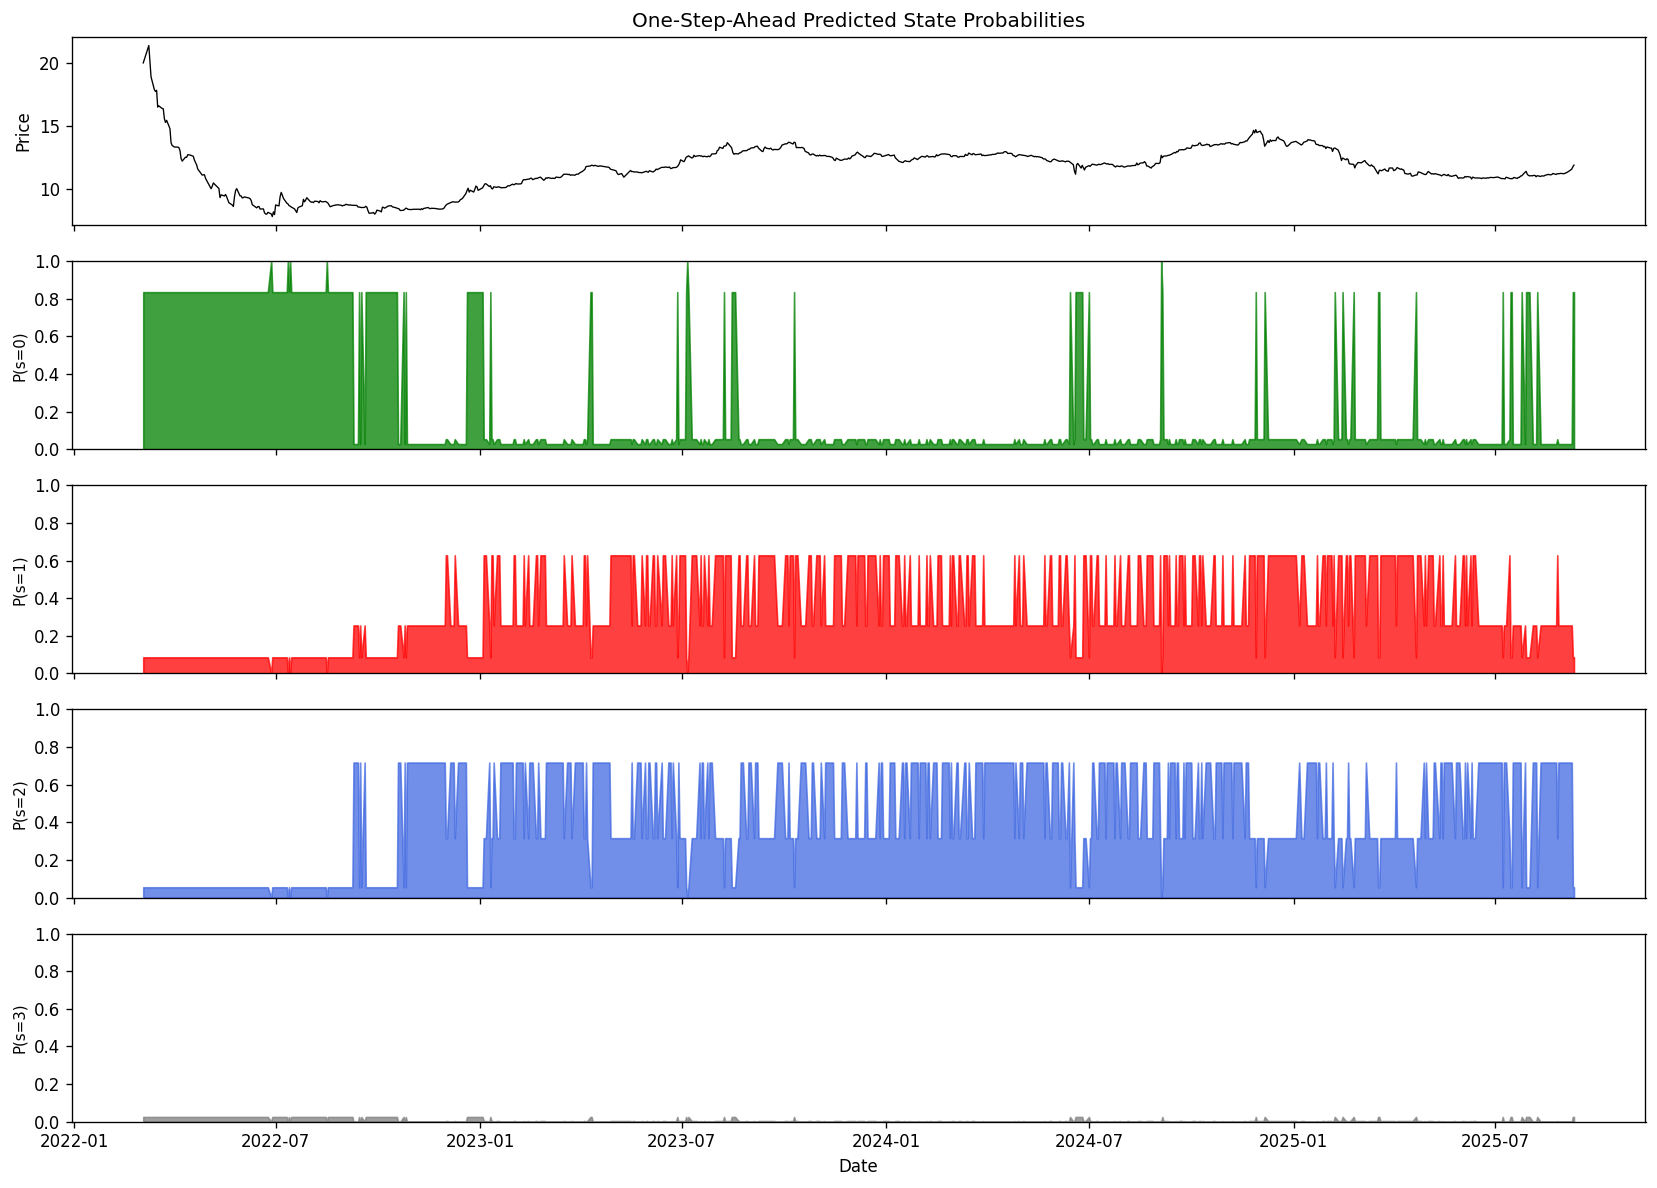

In [20]:
# Predicted state probability time series
fig,axes=plt.subplots(N_HMM_STATES+1,1,figsize=(14,10),sharex=True)
daily_close_pred=candles['pr_close'].resample('D').last().reindex(dates_pred)
axes[0].plot(dates_pred,daily_close_pred.values,lw=0.8,color='black')
axes[0].set_ylabel('Price'); axes[0].set_title('One-Step-Ahead Predicted State Probabilities')
for k in range(N_HMM_STATES):
    axes[k+1].fill_between(dates_pred,pred_probs[:,k],alpha=0.75,color=STATE_COLORS[k])
    axes[k+1].set_ylabel(f'P(s={k})',fontsize=9); axes[k+1].set_ylim(0,1)
axes[-1].set_xlabel('Date'); plt.tight_layout(); plt.show()

## 10. Forward Return Analysis by Predicted State

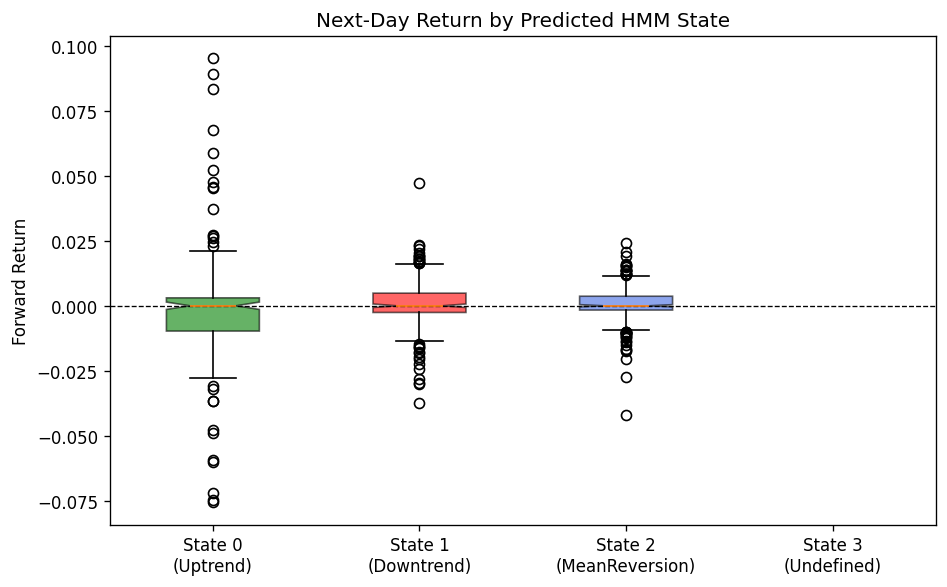

In [21]:
daily_fwd = candles['pr_close'].resample('D').last().pct_change().shift(-1)
df_result['forward_return'] = df_result.index.map(daily_fwd.to_dict())

print(f'{"State":<10}{"Regime":<17}{"Mean":>8}{"Std":>8}{"Sharpe":>8}{"Win%":>7}{"N":>5}')
print('-'*65)
for k in range(N_HMM_STATES):
    rd=df_result[df_result['pred_state']==k]['forward_return'].dropna()
    mean,std=rd.mean(),rd.std(); sharpe=mean/std if std>0 else 0
    print(f'  {k:<8}{STATE_TO_REGIME[k]:<17}{mean:>8.4f}{std:>8.4f}{sharpe:>8.3f}{(rd>0).mean():>7.1%}{len(rd):>5}')

fig,ax=plt.subplots(figsize=(8,5))
data_by_state=[df_result[df_result['pred_state']==k]['forward_return'].dropna().values for k in range(N_HMM_STATES)]
bp=ax.boxplot(data_by_state,patch_artist=True,notch=True)
for patch,color in zip(bp['boxes'],STATE_COLORS): patch.set_facecolor(color); patch.set_alpha(0.6)
ax.axhline(0,color='k',ls='--',lw=0.8)
ax.set(xticklabels=[f'State {k}\n({STATE_TO_REGIME[k]})' for k in range(N_HMM_STATES)],
       ylabel='Forward Return',title='Next-Day Return by Predicted HMM State')
plt.tight_layout(); plt.show()

## 11. MA-Crossover Backtest (Regime-Filtered)

In [22]:
def backtest_ma_crossover(candles_5min, df_result):
    """
    MA(6)/MA(18) crossover strategy filtered by HMM predicted regime.

    Entry: Uptrend  -> long  on cross-up
           Downtrend -> short on cross-down
    Exit:  forced at EOD close.
    Execution: entry at OPEN of bar following signal (realistic fill).
    Costs: NOT included. Add bid-ask spread (5-10 pips) for realistic estimate.
    """
    df = candles_5min.copy()
    df = df[df.index.dayofweek<5]
    df['ma_fast']    = df['pr_close'].rolling(6).mean()
    df['ma_slow']    = df['pr_close'].rolling(18).mean()
    df['fast_above'] = df['ma_fast']>df['ma_slow']
    df['cross_up']   = df['fast_above'] & ~df['fast_above'].shift(1).fillna(False)
    df['cross_down'] = ~df['fast_above'] & df['fast_above'].shift(1).fillna(False)
    df['date']       = df.index.date
    df['regime']     = pd.Series(df['date']).map(df_result['pred_regime'].to_dict()).values
    df['pnl']        = 0.0
    current_pos=0; entry_price=0.0; entry_idx=None; trades=[]

    for i in range(1,len(df)):
        row=df.iloc[i]; prev_row=df.iloc[i-1]; idx=df.index[i]
        is_eod=(i==len(df)-1) or (df.index[i].date()!=df.index[i+1].date())
        if current_pos!=0 and is_eod:
            exit_price=row['pr_close']; trade_pnl=(exit_price-entry_price)*current_pos
            df.at[idx,'pnl']=trade_pnl
            trades.append(dict(entry_time=entry_idx,exit_time=idx,
                               side='long' if current_pos>0 else 'short',
                               entry_price=entry_price,exit_price=exit_price,pnl=trade_pnl))
            current_pos=0
        if current_pos==0 and not pd.isna(row['regime']):
            next_open=df.iloc[i+1]['pr_open'] if i<len(df)-1 else row['pr_close']
            if   row['regime']=='Uptrend'   and prev_row['cross_up']:   current_pos,entry_price,entry_idx=1, next_open,idx
            elif row['regime']=='Downtrend' and prev_row['cross_down']: current_pos,entry_price,entry_idx=-1,next_open,idx

    df['cum_pnl']=df['pnl'].cumsum()
    return {'equity_curve':df['cum_pnl'],'trades':pd.DataFrame(trades),
            'total_pnl':df['pnl'].sum(),'df_with_signals':df}


bt = backtest_ma_crossover(candles, df_result)
print(f'Total P&L   : {bt["total_pnl"]:.4f}')
print(f'Trade count : {len(bt["trades"])}')
if len(bt['trades'])>0:
    tdf=bt['trades']; win_rate=(tdf['pnl']>0).mean()
    avg_win=tdf[tdf['pnl']>0]['pnl'].mean() if (tdf['pnl']>0).any() else 0
    avg_loss=tdf[tdf['pnl']<0]['pnl'].mean() if (tdf['pnl']<0).any() else 0
    print(f'Win rate    : {win_rate:.1%}')
    print(f'Avg win / loss: {avg_win:.4f} / {avg_loss:.4f}')
    if avg_loss!=0: print(f'Profit factor: {abs(avg_win*win_rate/(avg_loss*(1-win_rate))):.2f}')

Total P&L   : 2.8918
Trade count : 507
Win rate    : 51.9%
Avg win / loss: 0.1015 / -0.0988
Profit factor: 1.11


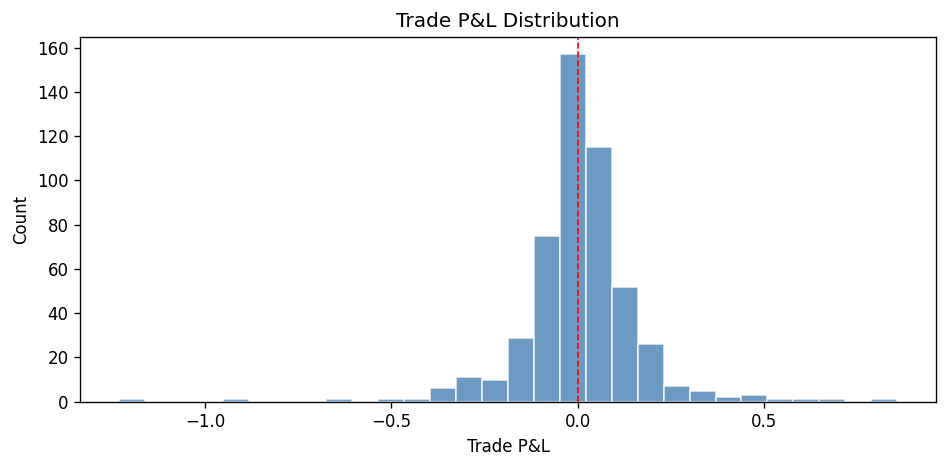

In [23]:
ec=bt['equity_curve']
fig,axes=plt.subplots(2,1,figsize=(14,7),sharex=True)
axes[0].plot(ec.index,ec.values,lw=1.2,color='steelblue')
axes[0].axhline(0,color='k',ls='--',lw=0.7)
axes[0].fill_between(ec.index,ec.values,0,where=ec.values>=0,alpha=0.2,color='green')
axes[0].fill_between(ec.index,ec.values,0,where=ec.values<0, alpha=0.2,color='red')
axes[0].set(ylabel='Cumulative P&L',title='MA-Crossover — HMM Regime Filter')
axes[1].plot(candles.index,candles['pr_close'].values,lw=0.6,color='black')
axes[1].set(ylabel='Price',xlabel='Date')
plt.tight_layout(); plt.show()

if len(bt['trades'])>0:
    fig,ax=plt.subplots(figsize=(8,4))
    ax.hist(bt['trades']['pnl'],bins=30,edgecolor='white',color='steelblue',alpha=0.8)
    ax.axvline(0,color='red',lw=1,ls='--')
    ax.set(xlabel='Trade P&L',ylabel='Count',title='Trade P&L Distribution')
    plt.tight_layout(); plt.show()

## 12. Save Outputs

In [ ]:
df_result.to_pickle('daily_hmm_predictions.pkl')
joblib.dump(model, 'hmm_model.pkl')
joblib.dump(scaler,'hmm_scaler.pkl')
print('Saved: daily_hmm_predictions.pkl, hmm_model.pkl, hmm_scaler.pkl')

## Appendix — Known Limitations

| Issue | Severity | Recommendation |
|---|---|---|
| State labelling is post-hoc | Medium | Verify STATE_TO_REGIME against emission means heatmap in 8.3 |
| One-step prediction O(T^2) | Low | Replace with online forward filter for T > 1000 |
| No transaction costs | High | Add 5-10 pip spread + impact estimate |
| Single in-sample eval | High | Walk-forward validation with expanding 60/20/20 windows |
| Full-covariance, D=15 | Medium | Check condition numbers in 8.3; use diagonal if ill-conditioned |
| vol_percentile includes current day | Low | Shift expanding apply by 1 day |
| Hurst from ~40 bars | Medium | Treat as noisy proxy; validate vs. R/S or DFA |